# Assignment 3

## Part 1

### Imports

In [1]:
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter
%matplotlib inline

### Load images and turn to grey scale


In [2]:
def load_gray(path: str) -> np.ndarray:
    """Load an image and convert to float64 grayscale [0, 255]."""
    img = Image.open(path).convert("L")
    return np.array(img, dtype=np.float64)

### Compute disparity code

In [3]:
def compute_disparity(Il, Ir, window_size, cost, max_disp=64):
    H, W = Il.shape
    half = window_size // 2
    disp_map = np.zeros((H, W), dtype=np.int32)
    
    # Padding to handle boundary pixels
    pad = half
    Il_pad = np.pad(Il, pad, mode="edge")
    Ir_pad = np.pad(Ir, pad, mode="edge")
    
    for row in range(H):
        pr = row + pad
        left_strip = Il_pad[pr - half : pr + half + 1, :]
        
        for col in range(W):
            pc = col + pad
            left_patch = left_strip[:, pc - half : pc + half + 1]
            best_cost = np.inf
            best_d = 0
            
            for d in range(0, max_disp + 1):
                rc = pc - d
                if rc - half < 0: break
                
                right_patch = Ir_pad[pr - half : pr + half + 1, rc - half : rc + half + 1]
                diff = left_patch - right_patch
                
                c_val = np.sum(np.abs(diff)) if cost == "SAD" else np.sum(diff**2)
                
                if c_val < best_cost:
                    best_cost, best_d = c_val, d
            disp_map[row, col] = best_d
    return disp_map

### Compute disparity but vectorized (for speed)

In [4]:
def compute_disparity_fast(Il, Ir, window_size, cost, max_disp=64):
    H, W = Il.shape
    disp_map = np.zeros((H, W), dtype=np.int32)
    best_cost = np.full((H, W), np.inf)
    
    for d in range(0, max_disp + 1):
        Ir_shifted = np.zeros_like(Ir)
        if d == 0: Ir_shifted = Ir
        else: Ir_shifted[:, d:] = Ir[:, :-d]
        
        diff = Il - Ir_shifted
        pixel_cost = np.abs(diff) if cost == "SAD" else diff**2
        
        # Calculate block cost using a box filter (summing the window)
        block_cost = uniform_filter(pixel_cost, size=window_size) * (window_size**2)
        
        mask = block_cost < best_cost
        best_cost[mask] = block_cost[mask]
        disp_map[mask] = d
    return disp_map

In [5]:
def run_experiment(left_name, right_name, max_disp=32):
    left_path = Path("stereo_materials") / left_name
    right_path = Path("stereo_materials") / right_name
    
    if not left_path.exists():
        print(f"File not found: {left_path}")
        return

    Il = load_gray(str(left_path))
    Ir = load_gray(str(right_path))
    
    window_sizes = [1, 5, 9]
    costs = ["SAD", "SSD"]
    
    fig, axes = plt.subplots(3, 2, figsize=(12, 15))
    fig.suptitle(f"Disparity Results for {left_name}", fontsize=16)

    for i, w in enumerate(window_sizes):
        for j, cost in enumerate(costs):
            disp = compute_disparity_fast(Il, Ir, w, cost, max_disp)
            ax = axes[i, j]
            im = ax.imshow(disp, cmap='plasma')
            ax.set_title(f"Window={w}, Cost={cost}")
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()

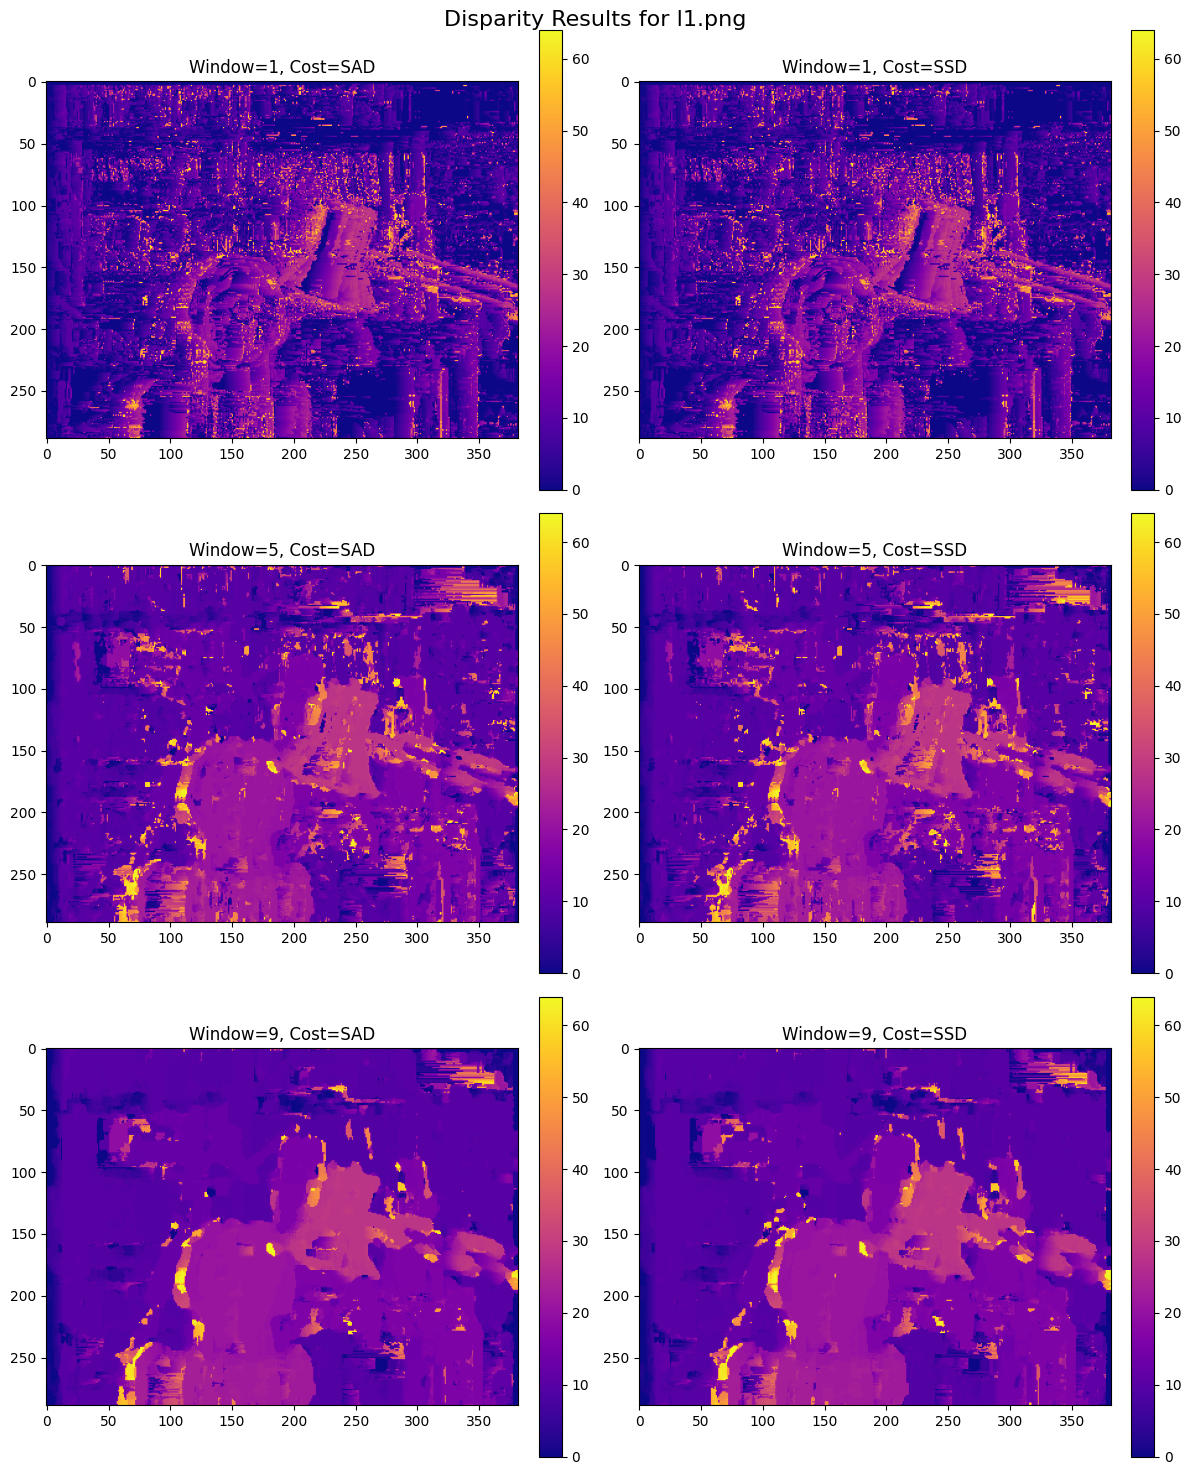

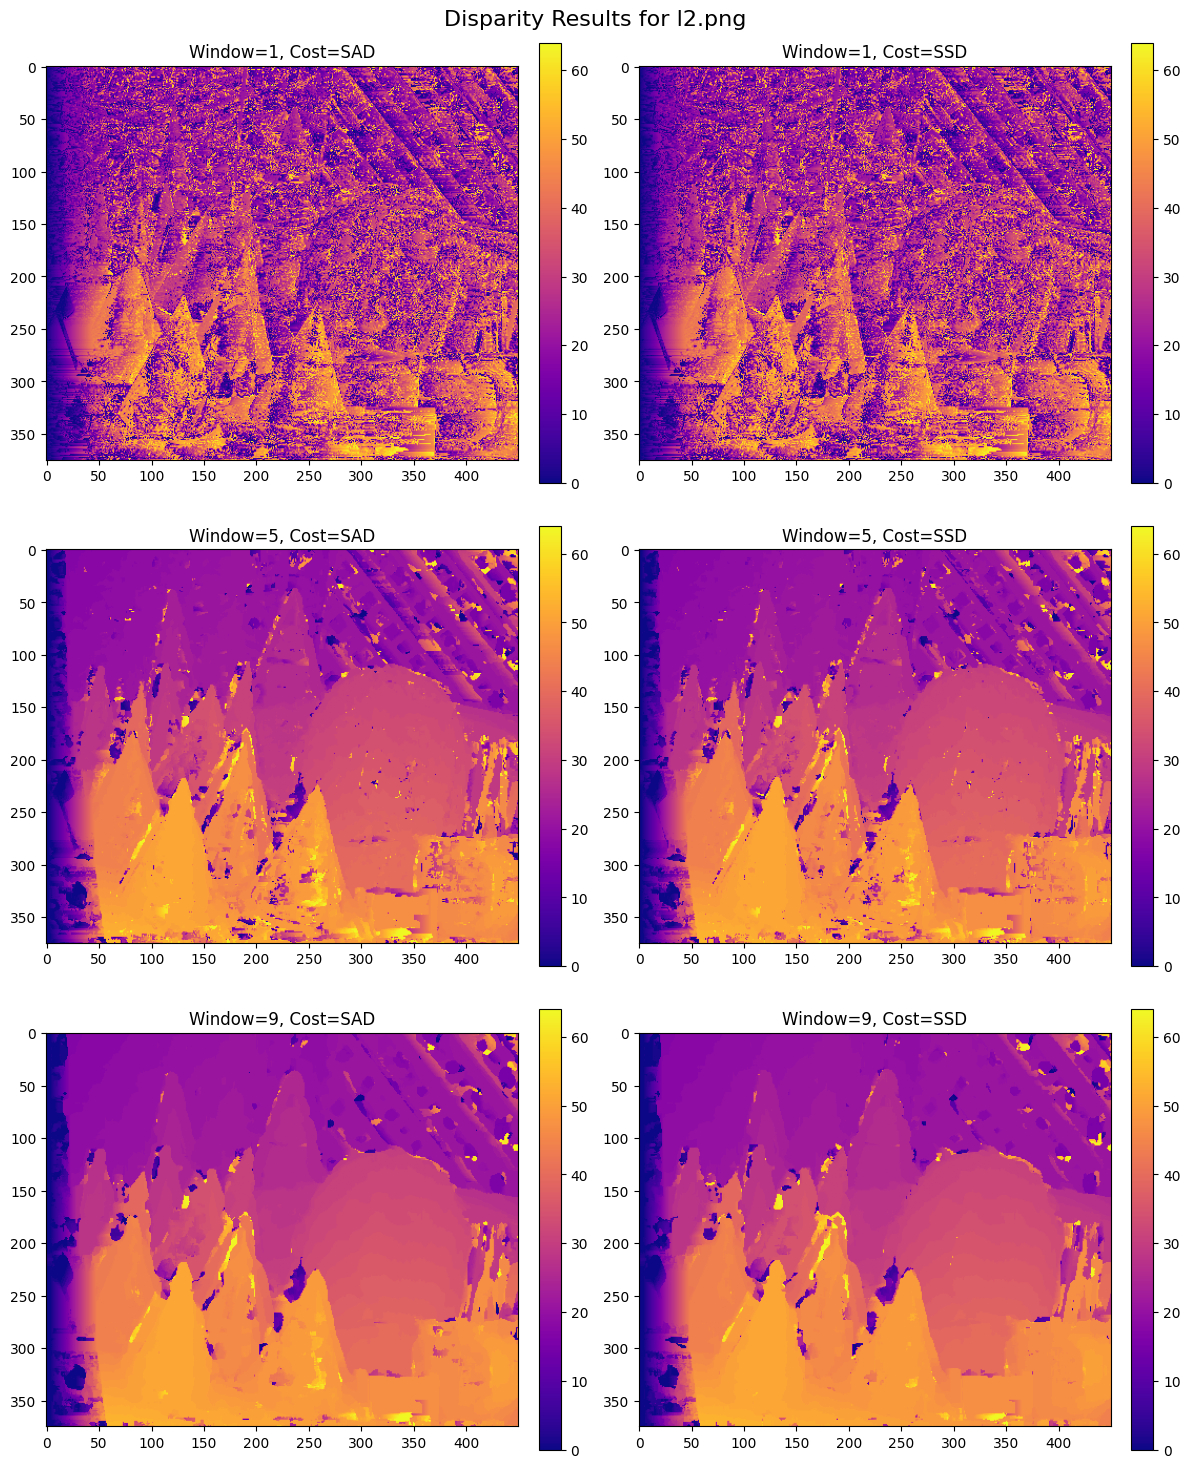

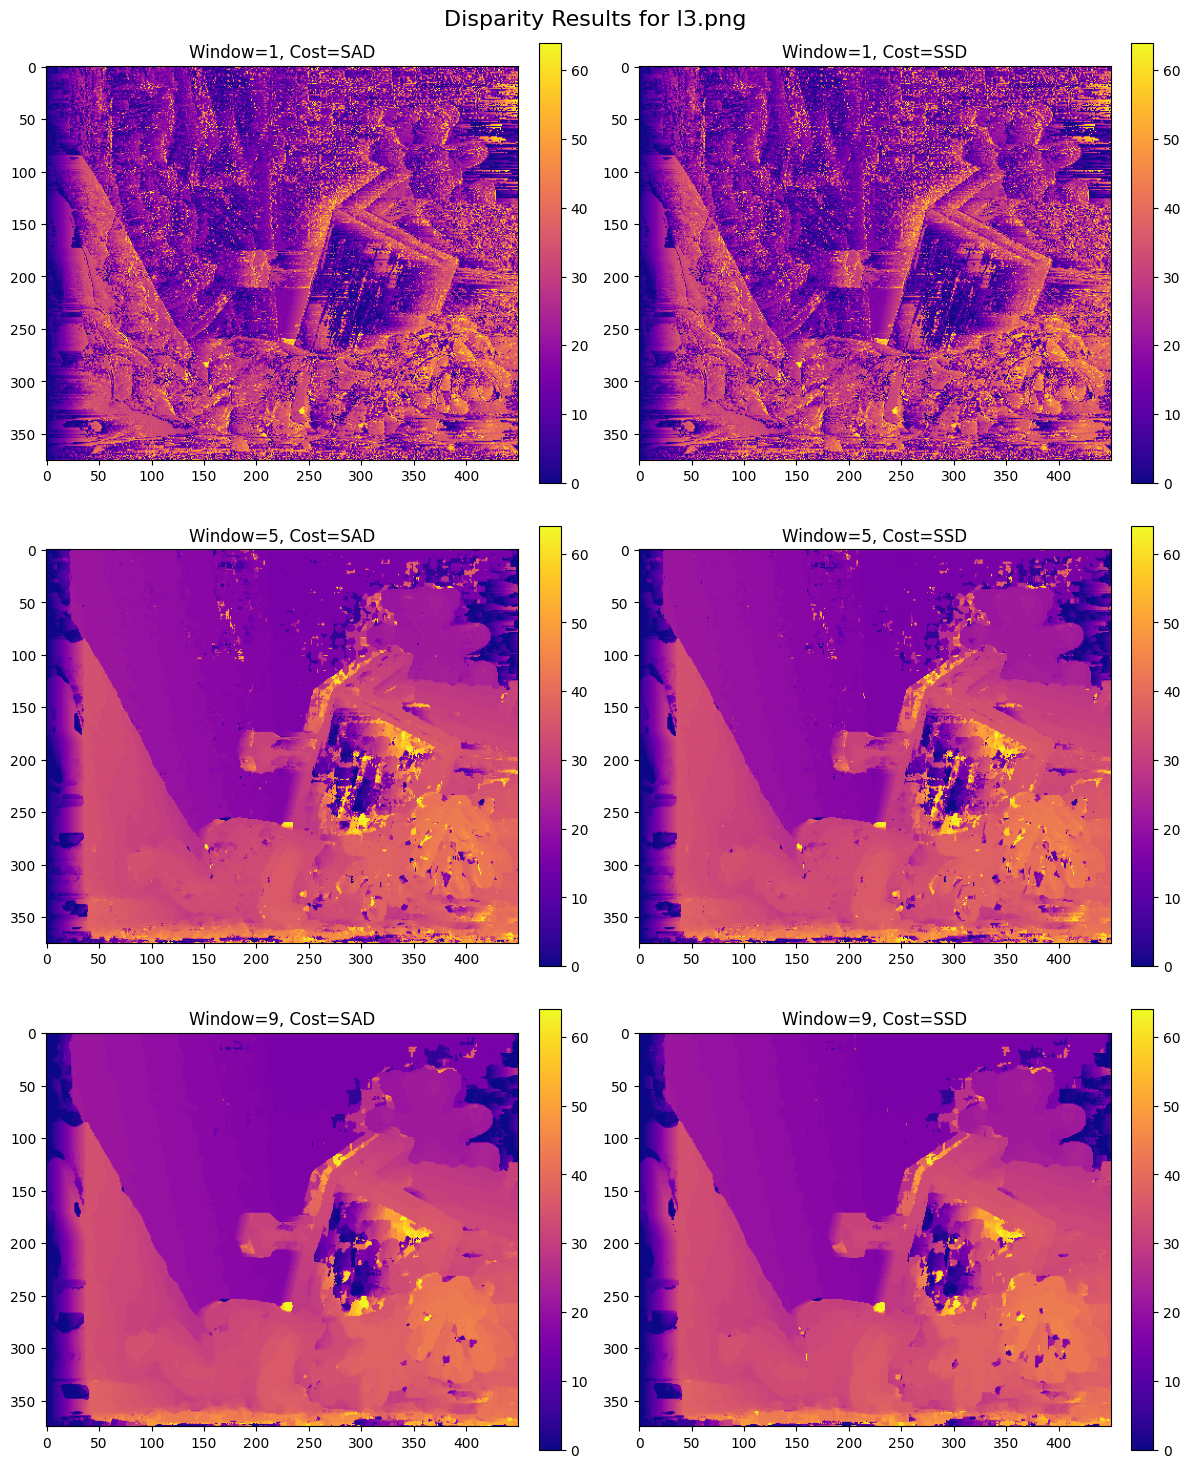

In [6]:
image_pairs = [("l1.png", "r1.png"), ("l2.png", "r2.png"), ("l3.png", "r3.png")]

for left, right in image_pairs:
    run_experiment(left, right, max_disp=64)